In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-p3rfiriz
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-p3rfiriz
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import clip
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
clip_model,preprocess = clip.load("ViT-B/32", device=device)

In [ ]:
data_path = "/content/drive/MyDrive/dataset/facesData"

train_data = datasets.ImageFolder(f"{data_path}/train", transform=preprocess)
test_data = datasets.ImageFolder(f"{data_path}/test", transform=preprocess)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
def extract_features(loader):
    features = []
    labels = []

    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)

            feats = clip_model.encode_image(images).float()

            features.append(feats.cpu())
            labels.append(lbls)

    return torch.cat(features), torch.cat(labels)

print("Extracting features...")
X_train, y_train = extract_features(train_loader)
X_test, y_test = extract_features(test_loader)

# Ensure float32
X_train = X_train.float()
X_test = X_test.float()

Extracting features...


In [ ]:
class StressModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

model = StressModel(X_train.shape[1]).to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 30
train_losses = []
train_accs = []

In [ ]:
for epoch in range(epochs):
    model.train()

    inputs = X_train.to(device)
    labels = y_train.float().unsqueeze(1).to(device)

    outputs = model(inputs)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

    acc = (preds == labels).sum().item() / len(labels)

    train_losses.append(loss.item())
    train_accs.append(acc)

    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

Epoch 1 | Loss: 0.6926 | Accuracy: 0.5173
Epoch 2 | Loss: 0.6915 | Accuracy: 0.5328
Epoch 3 | Loss: 0.6899 | Accuracy: 0.5522
Epoch 4 | Loss: 0.6891 | Accuracy: 0.5695
Epoch 5 | Loss: 0.6878 | Accuracy: 0.5803
Epoch 6 | Loss: 0.6867 | Accuracy: 0.5997
Epoch 7 | Loss: 0.6853 | Accuracy: 0.6188
Epoch 8 | Loss: 0.6846 | Accuracy: 0.6165
Epoch 9 | Loss: 0.6831 | Accuracy: 0.6321
Epoch 10 | Loss: 0.6820 | Accuracy: 0.6444
Epoch 11 | Loss: 0.6808 | Accuracy: 0.6437
Epoch 12 | Loss: 0.6793 | Accuracy: 0.6576
Epoch 13 | Loss: 0.6776 | Accuracy: 0.6652
Epoch 14 | Loss: 0.6764 | Accuracy: 0.6657
Epoch 15 | Loss: 0.6752 | Accuracy: 0.6702
Epoch 16 | Loss: 0.6735 | Accuracy: 0.6679
Epoch 17 | Loss: 0.6718 | Accuracy: 0.6752
Epoch 18 | Loss: 0.6703 | Accuracy: 0.6757
Epoch 19 | Loss: 0.6684 | Accuracy: 0.6831
Epoch 20 | Loss: 0.6667 | Accuracy: 0.6805
Epoch 21 | Loss: 0.6643 | Accuracy: 0.6873
Epoch 22 | Loss: 0.6629 | Accuracy: 0.6803
Epoch 23 | Loss: 0.6612 | Accuracy: 0.6868
Epoch 24 | Loss: 0.6

In [ ]:
model.eval()

with torch.no_grad():
    inputs = X_test.to(device)
    labels = y_test.float().unsqueeze(1).to(device)

    outputs = model(inputs)

    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

y_true = labels.cpu().numpy()
y_pred = preds.cpu().numpy()

print("Accuracy:", (y_true == y_pred).mean())
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

Accuracy: 0.707258064516129
              precision    recall  f1-score   support

         0.0       0.68      0.76      0.72      1233
         1.0       0.74      0.65      0.69      1247

    accuracy                           0.71      2480
   macro avg       0.71      0.71      0.71      2480
weighted avg       0.71      0.71      0.71      2480



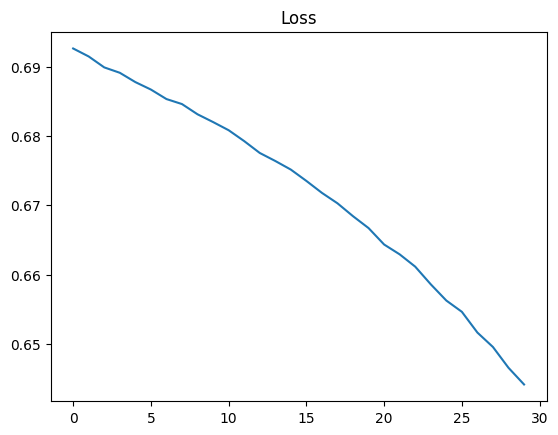

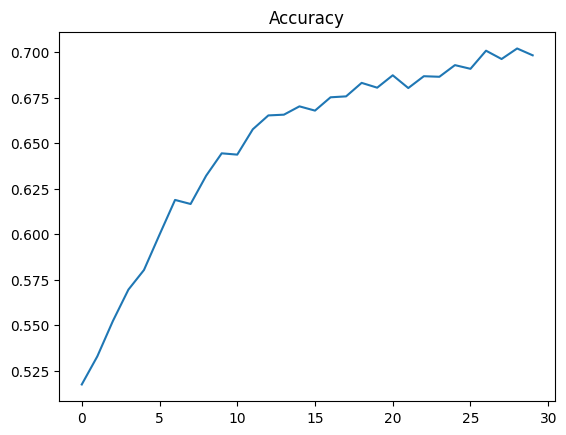

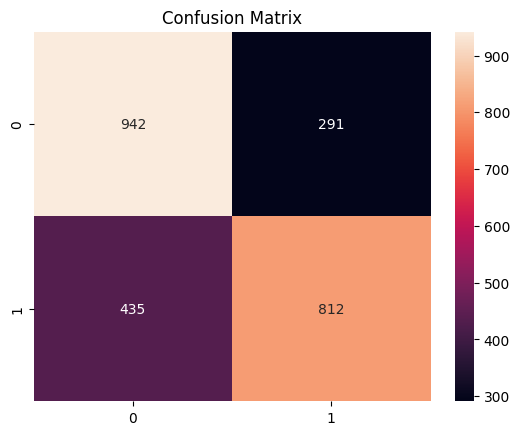

In [ ]:
plt.plot(train_losses)
plt.title("Loss")
plt.show()

plt.plot(train_accs)
plt.title("Accuracy")
plt.show()

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

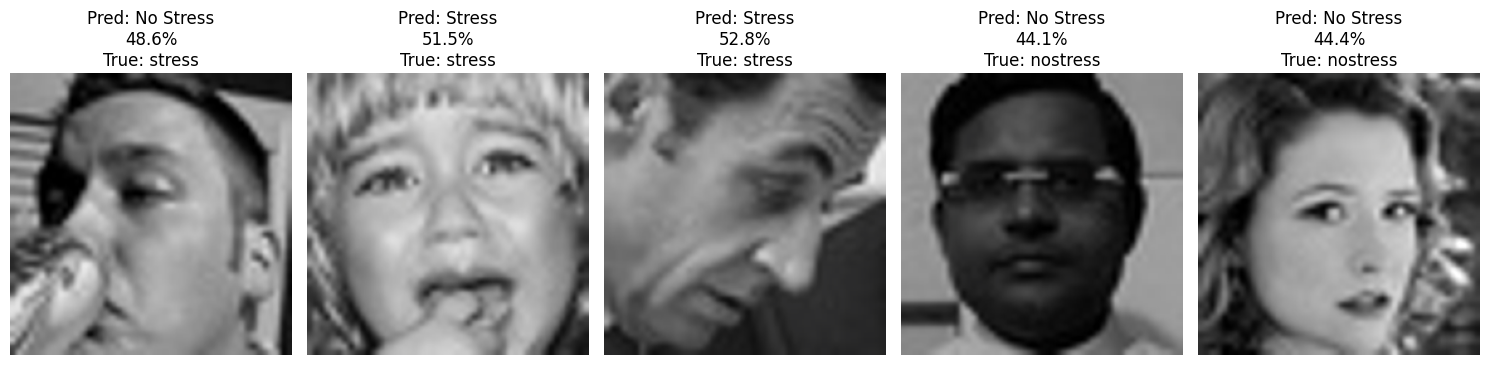

In [ ]:
import matplotlib.pyplot as plt
import random
import torch
def denormalize(img):
    img = img.clone().cpu()

    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073])
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711])

    img = img * std[:, None, None] + mean[:, None, None]
    img = img.clamp(0, 1)

    return img
def show_predictions(dataset, num=5):
    model.eval()

    plt.figure(figsize=(15,5))
    indices = random.sample(range(len(dataset)), num)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        input_img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            feat = clip_model.encode_image(input_img).float()
            output = model(feat)
            prob = torch.sigmoid(output).item()

        stress_percent = prob * 100
        pred_label = "Stress" if prob > 0.5 else "No Stress"
        true_label = dataset.classes[label]

        plt.subplot(1, num, i+1)
        plt.imshow(denormalize(img).permute(1,2,0))
        plt.title(f"Pred: {pred_label}\n{stress_percent:.1f}%\nTrue: {true_label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
show_predictions(test_data, num=5)